In [1]:
# 2. Setup: temukan data.yaml & pilih device otomatis
from pathlib import Path
import torch

# ROOT = folder project (parent dari notebooks/). Sesuaikan bila jalan di Colab.
ROOT = Path.cwd()
if not (ROOT / "dataset_cleaned").exists():
    ROOT = ROOT.parent  # jalan dari dalam notebooks/
DATA = ROOT / "dataset_cleaned" / "data.yaml"
assert DATA.exists(), f"data.yaml tidak ditemukan: {DATA}"

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("data  :", DATA)
print("device:", DEVICE, "(" + (torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU") + ")")

data  : c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\data.yaml
device: cpu (CPU)


In [7]:
import yaml

DATASET_DIR = ROOT / "dataset_cleaned"

cfg = {
    "path": str(DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 2,
    "names": ["parking_violation", "parking_normal"],
}

with open(DATA, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

for key in ["train", "val", "test"]:
    p = DATASET_DIR / cfg[key]
    print(f"{key:5s}: {p} -> {'ADA' if p.exists() else 'TIDAK ADA'}")

train: c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\train\images -> ADA
val  : c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\valid\images -> ADA
test : c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\test\images -> ADA


In [13]:
# 3. Train
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA),
    epochs=15,
    imgsz=320,
    batch=8,
    device=DEVICE,                       
    patience=8,
    cache=False,
    workers=4,
    project=str(ROOT / "runs"),
    name="parking_yolov8n_v2",           
    mosaic=0.0, mixup=0.0, copy_paste=0.0,
)

New https://pypi.org/project/ultralytics/8.4.171 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.10.11 torch-2.14.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf

In [14]:
# 4. Evaluasi di test split (per-kelas)
best = YOLO(results.save_dir / "weights" / "best.pt")   
metrics = best.val(data=str(DATA), split="test", device=DEVICE)
print("mAP50-95:", metrics.box.map)
print("mAP50   :", metrics.box.map50)
for i, name in metrics.names.items():
    print(f"  {name:16} AP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.142  Python-3.10.11 torch-2.14.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.30.0 ms, read: 3.81.8 MB/s, size: 56.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\test\labels... 1010 images, 82 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1010/1010 319.6it/s 3.2s0.0s
val: New cache created: C:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 2.0it/s 31.4s0.5ss
                   all       1010      35033       0.95      0.941      0.987      0.844
     parking_violation        770      18371      0.928      0.

In [16]:
# 5. Prediksi contoh (visual sanity check)
sample_candidates = sorted((ROOT / "dataset_cleaned" / "test" / "images").glob("*.jpg"))
assert sample_candidates, "Tidak ada file .jpg di folder test/images"
sample = sample_candidates[0]

best.predict(sample, save=True, conf=0.25, device=DEVICE)
print("hasil tersimpan di folder runs/.../predict")


image 1/1 c:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\dataset_cleaned\test\images\-2024-10-24-000049_png.rf.aff5c5314454048586976d722ffee5c3.jpg: 320x320 1 parking_violation, 72.6ms
Speed: 14.3ms preprocess, 72.6ms inference, 4.0ms postprocess per image at shape (1, 3, 320, 320)
Results saved to C:\Users\LENOVO\Smart-EvaluationSensing-Statistical-System\runs\detect\predict-8
hasil tersimpan di folder runs/.../predict


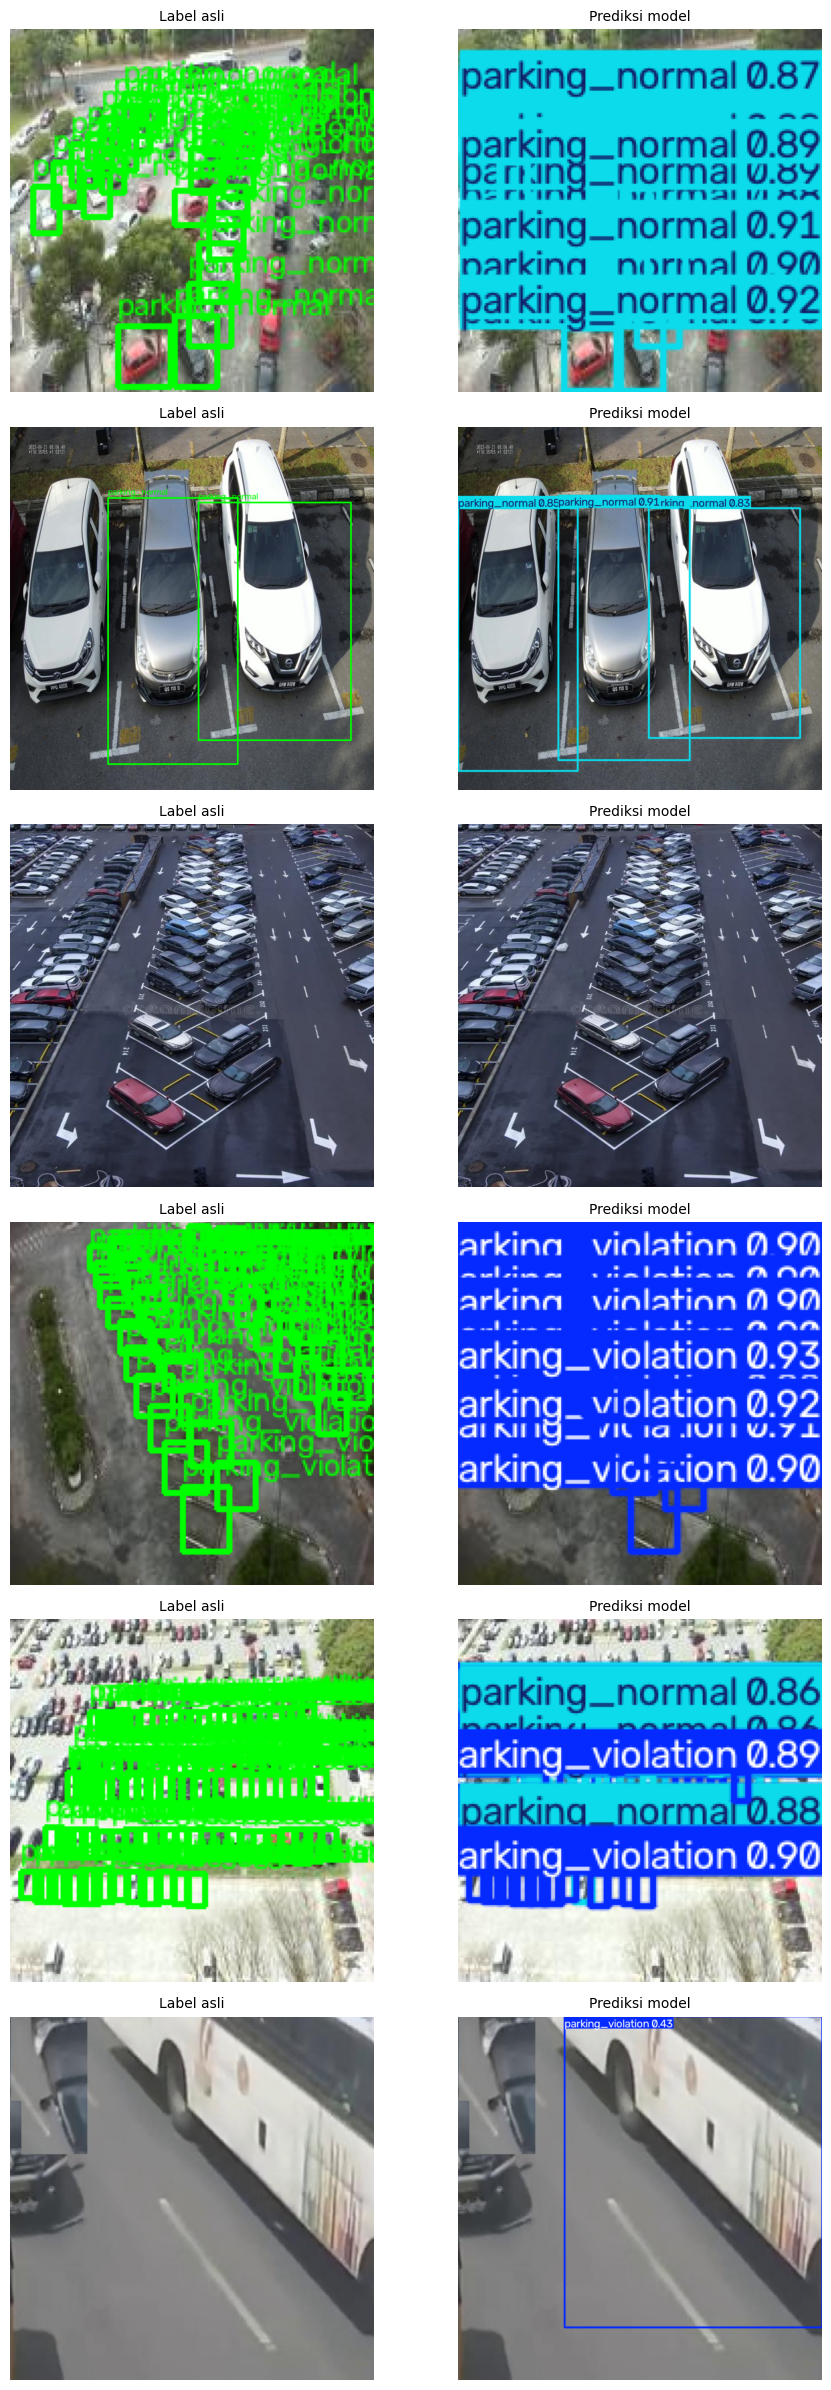

In [19]:
# 6. Bandingkan label asli vs prediksi model
import random
import cv2
import matplotlib.pyplot as plt

random.seed(42)
IMG_DIR = ROOT / "dataset_cleaned" / "test" / "images"
LBL_DIR = ROOT / "dataset_cleaned" / "test" / "labels"
CLASS_NAMES = best.names   # dict {0: ..., 1: ...}

def draw_gt(img, label_path):
    h, w = img.shape[:2]
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            c = int(p[0])
            cx, cy, bw, bh = map(float, p[1:])
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, CLASS_NAMES[c], (x1, max(y1 - 5, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img

images = [f for f in IMG_DIR.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
samples = random.sample(images, 6)

fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))

for row, img_path in enumerate(samples):
    img = cv2.imread(str(img_path))

    gt_img = draw_gt(img.copy(), LBL_DIR / (img_path.stem + ".txt"))
    pred_img = best.predict(str(img_path), conf=0.25, device=DEVICE, verbose=False)[0].plot()

    axes[row, 0].imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title("Label asli", fontsize=10)
    axes[row, 1].imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title("Prediksi model", fontsize=10)
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

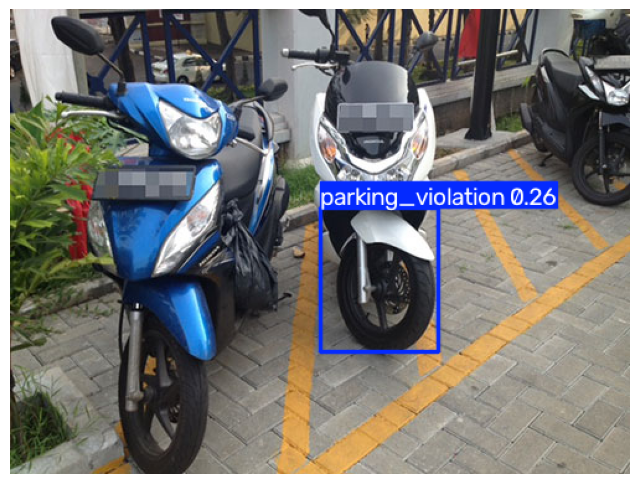

parking_violation  confidence = 0.26


In [20]:
# 7. Tes model dengan foto sendiri (motor)
from pathlib import Path
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Model hasil training (sesuaikan nama run kalau foldernya berbeda)
MODEL_PATH = ROOT / "runs" / "parking_yolov8n_v2" / "weights" / "best.pt"
best = YOLO(str(MODEL_PATH))

# Ganti dengan path foto motor kamu
FOTO = Path(r"C:/Users/LENOVO/Downloads/parkir.jpg")
assert FOTO.exists(), f"Foto tidak ditemukan: {FOTO}"

result = best.predict(str(FOTO), conf=0.25, imgsz=320, device=DEVICE, verbose=False)[0]

# Tampilkan gambar dengan kotak prediksi
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Cetak hasil deteksi dalam teks
if len(result.boxes) == 0:
    print("Tidak ada objek terdeteksi.")
else:
    for box in result.boxes:
        nama = result.names[int(box.cls)]
        print(f"{nama:18s} confidence = {float(box.conf):.2f}")

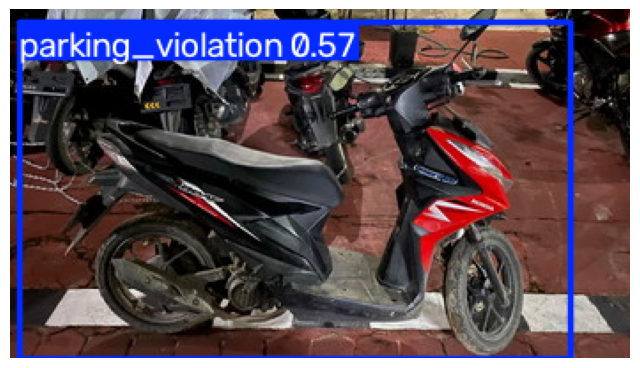

parking_violation  confidence = 0.57


In [22]:
# 7. Tes model dengan foto sendiri (motor)
from pathlib import Path
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Model hasil training (sesuaikan nama run kalau foldernya berbeda)
MODEL_PATH = ROOT / "runs" / "parking_yolov8n_v2" / "weights" / "best.pt"
best = YOLO(str(MODEL_PATH))

# Ganti dengan path foto motor kamu
FOTO = Path(r"C:/Users/LENOVO/Downloads/parkir2.jpg")
assert FOTO.exists(), f"Foto tidak ditemukan: {FOTO}"

result = best.predict(str(FOTO), conf=0.25, imgsz=320, device=DEVICE, verbose=False)[0]

# Tampilkan gambar dengan kotak prediksi
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Cetak hasil deteksi dalam teks
if len(result.boxes) == 0:
    print("Tidak ada objek terdeteksi.")
else:
    for box in result.boxes:
        nama = result.names[int(box.cls)]
        print(f"{nama:18s} confidence = {float(box.conf):.2f}")